In [9]:
%load_ext autoreload

%autoreload 2
import numpy as np
import corner, sys
import emcee
import getdist
from getdist import plots, MCSamples
%matplotlib inline
import matplotlib.pyplot as plt
sys.path.append('../../modules/')
import numpy as np
#plt.switch_backend("Qt5Agg")
params = {
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "text.usetex": True,
    "figure.figsize": [3.386, 3.386],
    "figure.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
}
plt.rcParams.update(params)

In [10]:
names = ['1','2','3','4','5','6']
labels = [r'\Omega_m', r'\sigma_8', r'\mu^\lambda_0', r'\mu^\lambda_m',r'\mu^\lambda_z',r'\sigma_{\ln\lambda, {\rm int}}']
settings={'mult_bias_correction_order':0,'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

In [11]:
n_cut=490000

In [12]:
n_cut=490000
path = '../../capish_sbi_data/config_sbi_DESlike6_corrected_standard_prior_6_params/samples_of_{}_posterior_with_data_flagship_like_sim.pkl'

t = np.load(path.format('count_log10m_masked'), allow_pickle = True)
N_log10m = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count+log10m masked (SBI)')

t = np.load(path.format('log10m_masked'), allow_pickle = True)
log10m = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'log10m (SBI)')

t = np.load(path.format('count_masked'), allow_pickle = True)
N_masked = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count-masked (SBI)')

t = np.load(path.format('count'), allow_pickle = True)
N = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count (SBI)')

t = np.load(path.format('Nm'), allow_pickle = True)
Nm = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'Nm (SBI)')

t = np.load(path.format('count_Nm'), allow_pickle = True)
count_Nm = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count+Nm (SBI)')

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [13]:
n_cut=490000
path = '../../capish_sbi_data/config_sbi_DESlike6_corrected_standard_prior_6_params/samples_of_{}_posterior_with_data_flagship_like_sim_one.pkl'

t = np.load(path.format('count'), allow_pickle = True)
N_onesim = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count (SBI, one sim)')

t = np.load(path.format('Nm'), allow_pickle = True)
Nm_onesim = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'Nm (SBI, one sim)')

t = np.load(path.format('count_Nm'), allow_pickle = True)
count_Nm_onesim = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count+Nm (SBI, one sim.)')

Removed no burn in
Removed no burn in
Removed no burn in


In [14]:
def read_mcmc(file):
    backend = emcee.backends.HDFBackend(file)
    chain = backend.get_chain(discard=0, thin=1, flat=True)  
    print(len(chain))
    return chain

In [15]:
params_fid=[0.319,0.813,3.5,1.72,0,0.2]
minimum = [0.2, 0.6, 
                                                        3.0, 1.3, 
                                                        -0.7, 0.1]
maximum = [0.45, 0.95, 
                                                        4.0, 2.1, 
                                                        0.7, 0.5]

In [16]:
print(minimum)

print(maximum)
range_ = {str(i+1): [minimum[i], maximum[i]] for i in range(len(params_fid))}
#range_ = {'1':[0.2, 0.5], '2':[0.6,0.9], '3':[2.5,4.5], '4':[1, 2.5],'5':[-1,1], '6':[0.1, 0.5], }

[0.2, 0.6, 3.0, 1.3, -0.7, 0.1]
[0.45, 0.95, 4.0, 2.1, 0.7, 0.5]


In [17]:
params_fid=[0.319,0.813,3.5,1.72,0,0.2]
#params_fid=[0.319,0.813,3.5,0.8,0.3]

In [18]:
markers={f'{i+1}':params_fid[i] for i in range(len(params_fid))}

In [26]:
n_cut=40000
settings={'mult_bias_correction_order':0,'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}
path = '../validation_capish_comparison_to_standard_approach/mcmc_chains/chains_{}.h5'

t = read_mcmc(path.format('count_only'))
N_mcmc = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count (analytic likelihood)')

t = read_mcmc(path.format('mass_only'))
m_mcmc = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'log10m (analytic likelihood)')

t = read_mcmc(path.format('count_mass'))
Nm_mcmc = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count+log10m (analytic likelihood)')

47250
Removed no burn in
47850
Removed no burn in
47250
Removed no burn in


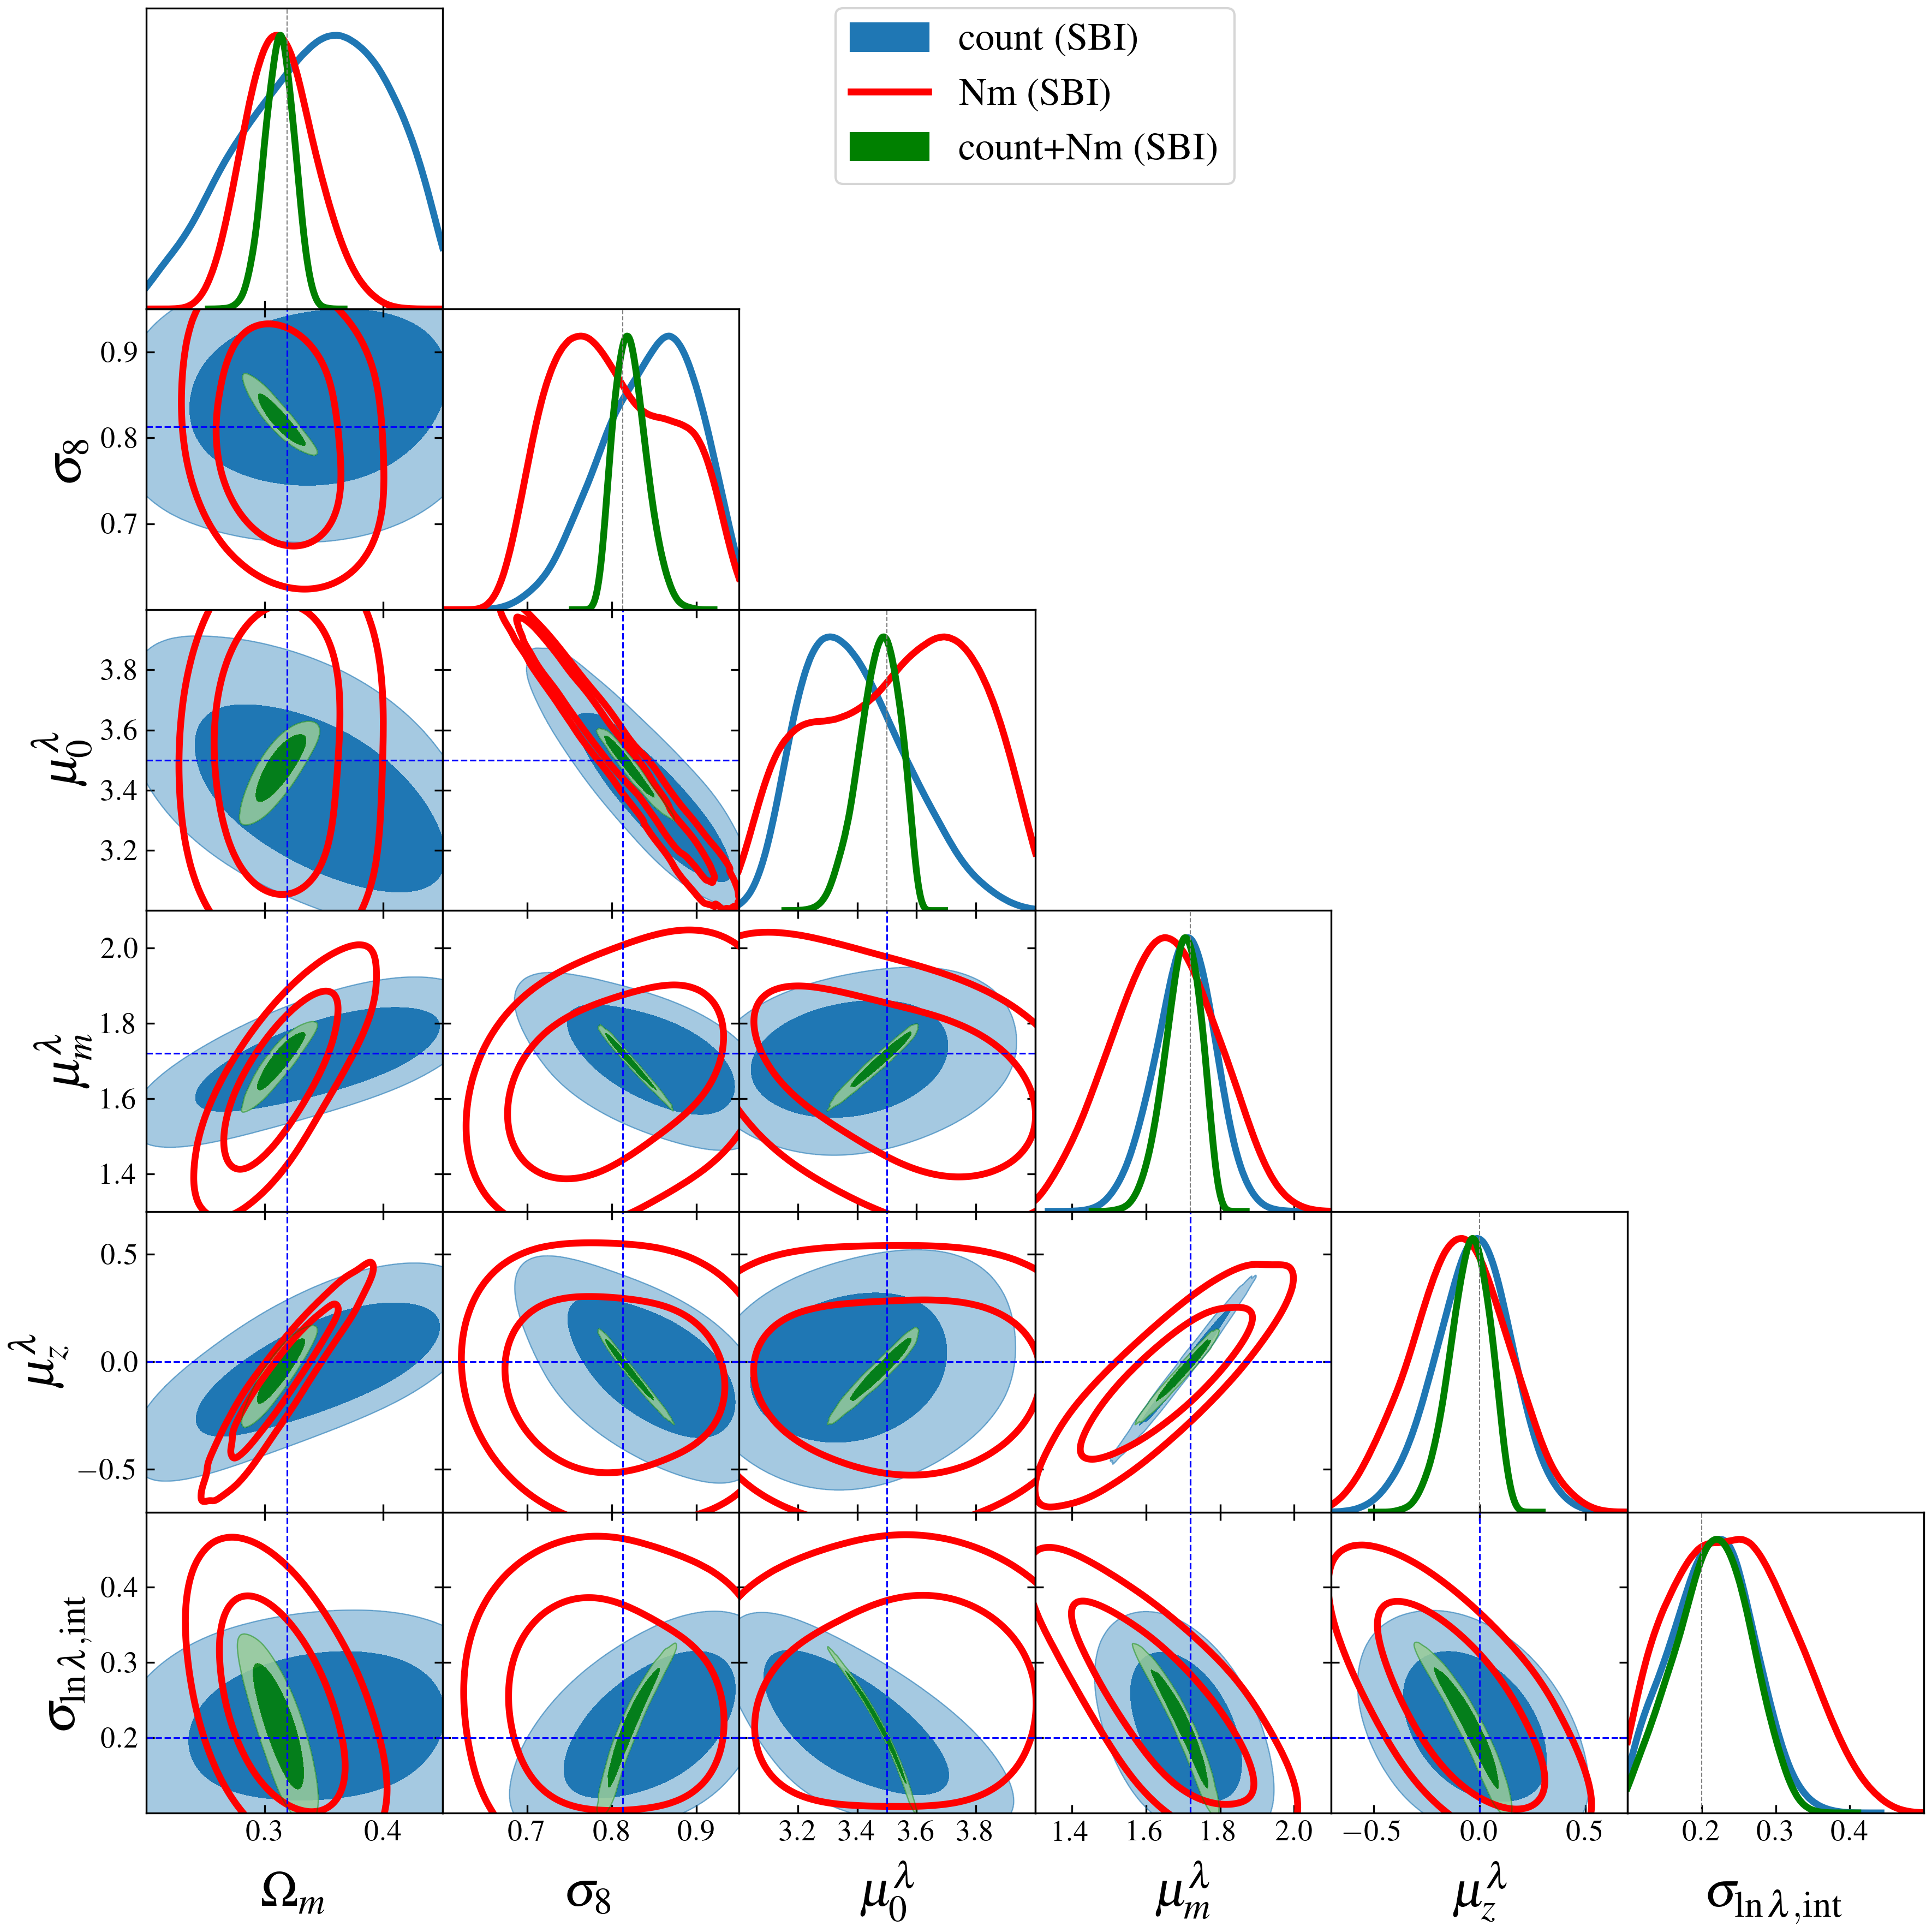

In [27]:
g = plots.get_subplot_plotter(subplot_size=2)
g.settings.lab_fontsize = 25
g.settings.axes_fontsize = 16
g.settings.legend_fontsize = 20
marker_args = {'lw':0.75, 'markersize':0.75, 'ls':'--','color':'b'}
#range_ = {'1':[0.2, 0.5], '2':[0.6,0.9], '3':[2.5,4.5], '4':[1, 2.5],'5':[-1,1], '6':[0.1, 0.5], }
g.triangle_plot([N, Nm, count_Nm, ],
                #[N_Nm_power_law_log10Mwl_no_scatter],
                filled=[True, False, True,False, False, False], 
                contour_colors = ['C0', 'r', 'g','b', 'r', 'g',  ], 
                contour_ls=['-','-','-','--','--','--',],
                contour_lws=[3,3,3,1.5,1.5,1.5],
                #shaded=[False, False, True],
                legend_fontsize = 10,
                params=['1','2','3','4','5','6'],
                markers=markers,
                param_limits = range_,
                fine_bins = 5,  
                marker_args = marker_args)
plt.savefig(f'mcmc_SBI.png', dpi = 300)

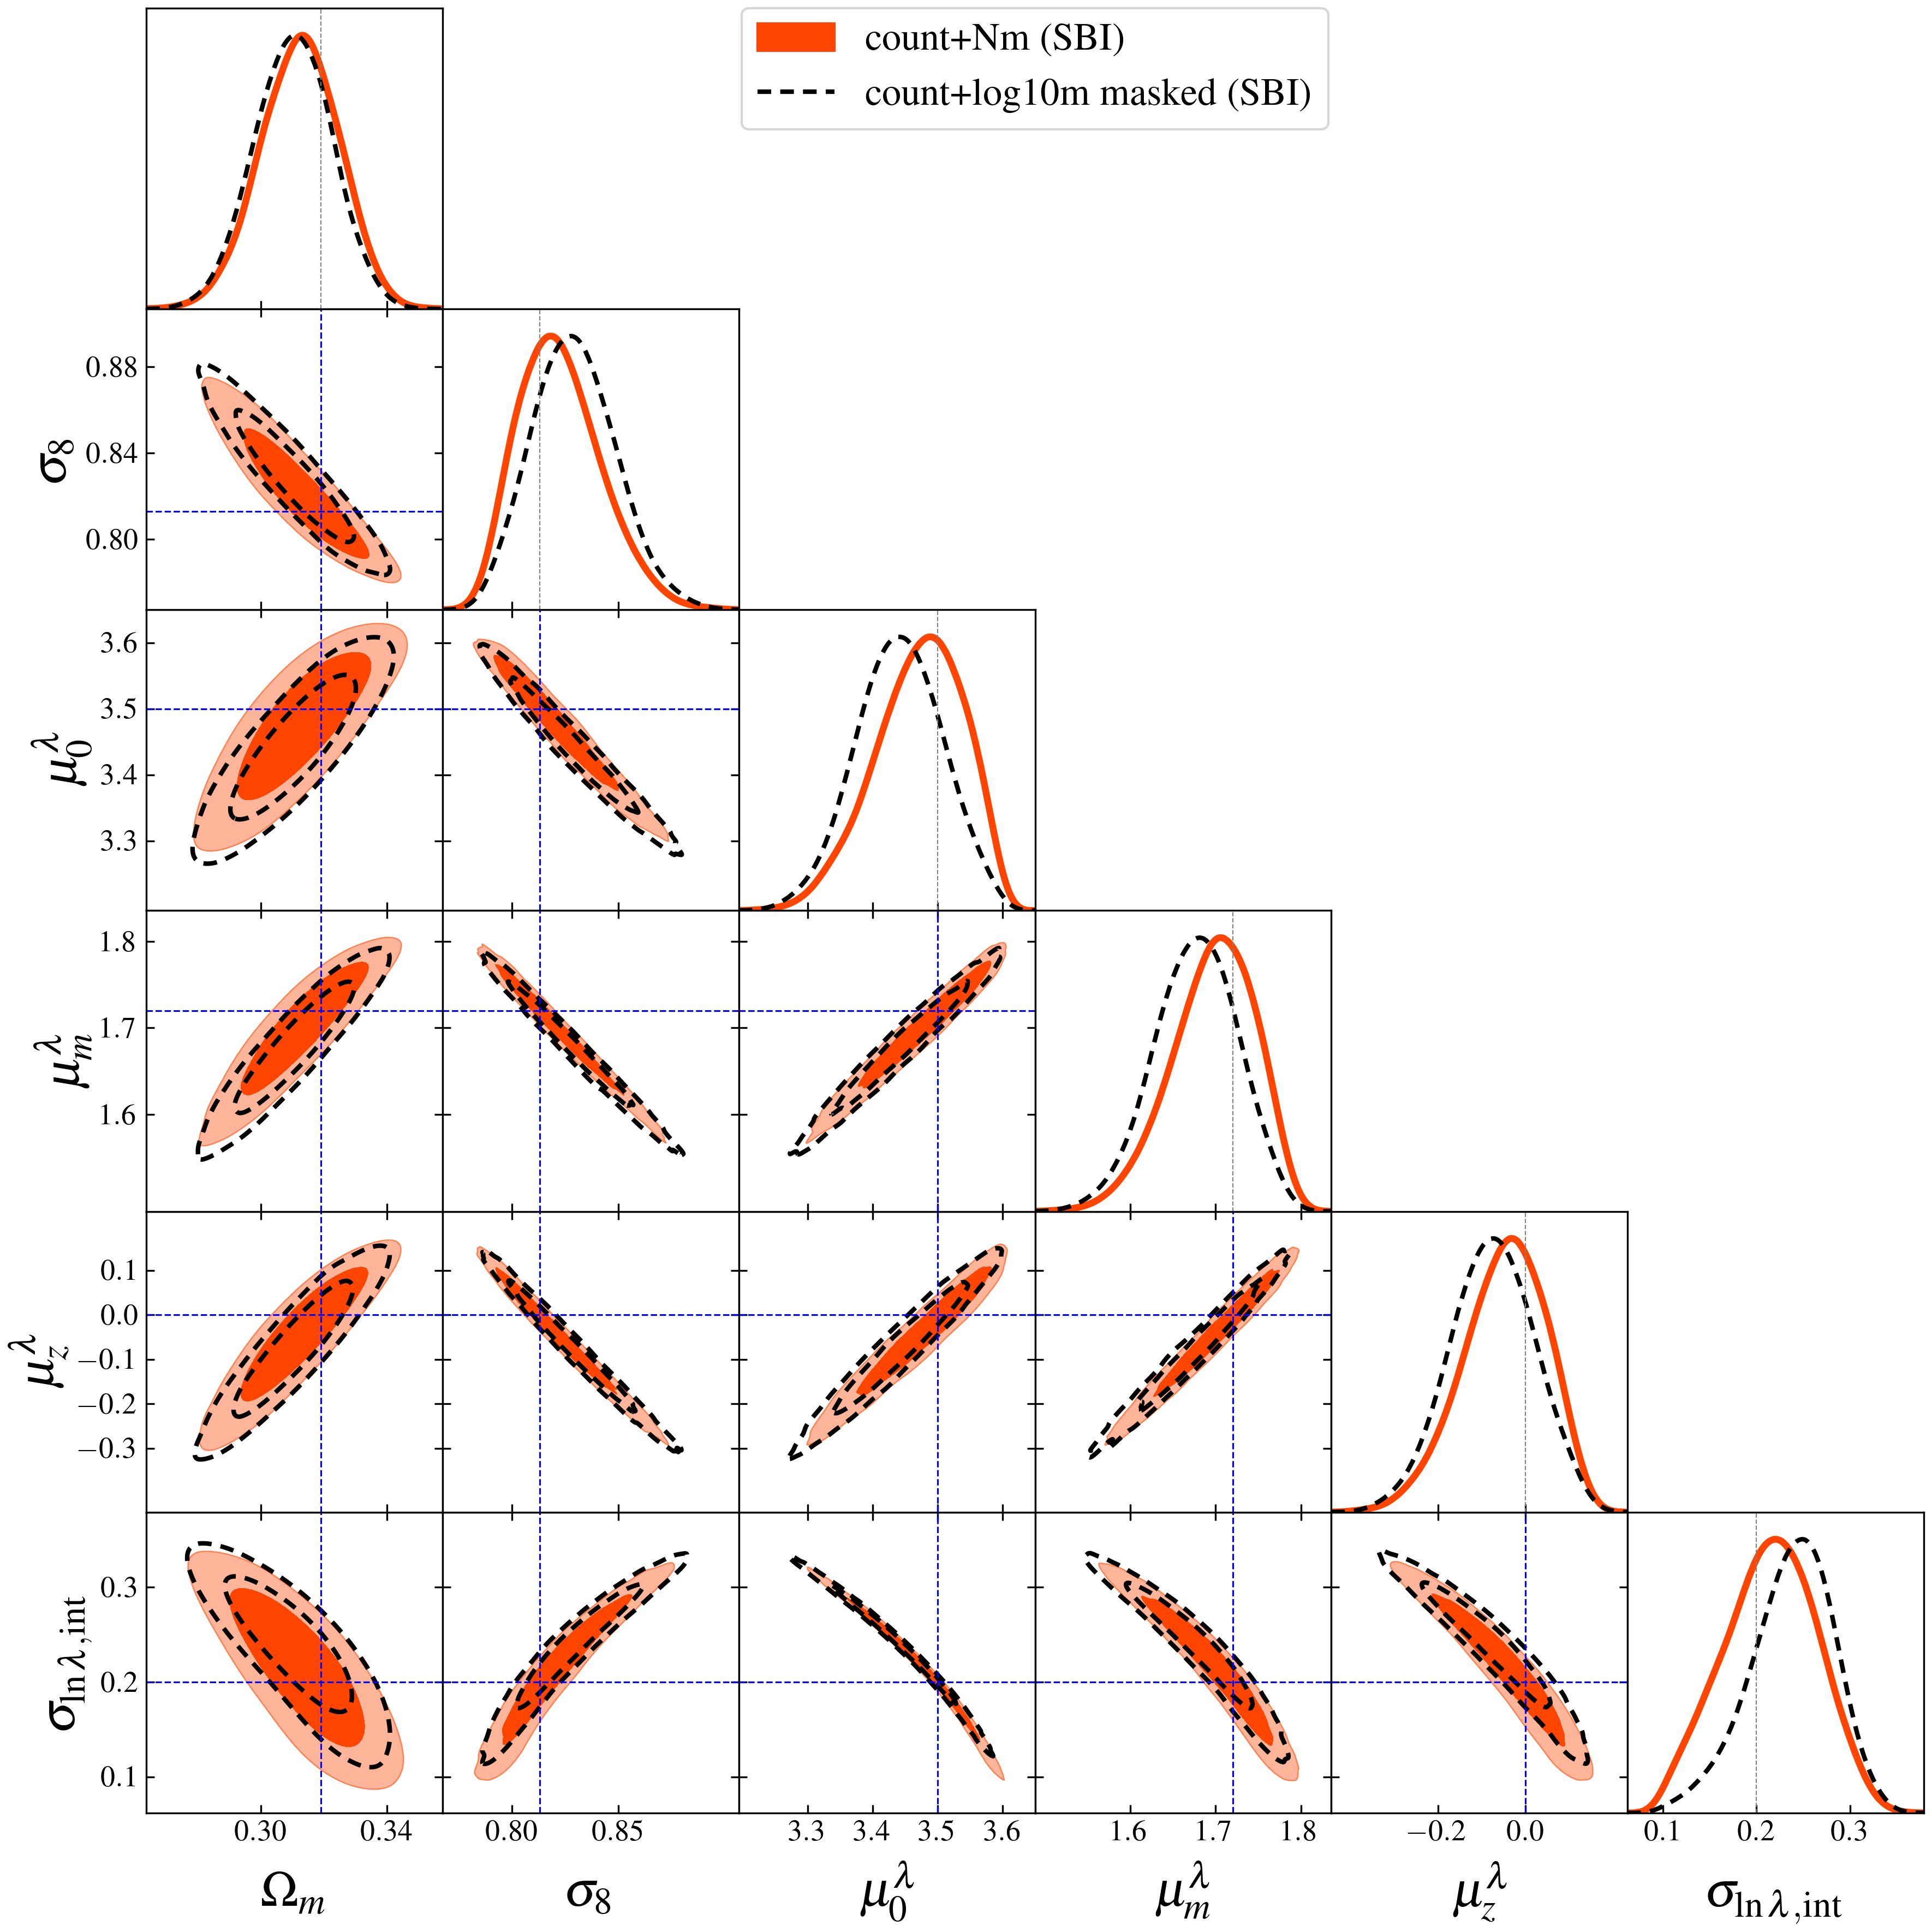

In [68]:
g = plots.get_subplot_plotter(subplot_size=2)
g.settings.lab_fontsize = 25
g.settings.axes_fontsize = 16
g.settings.legend_fontsize = 20
marker_args = {'lw':0.75, 'markersize':0.75, 'ls':'--','color':'b'}
#range_ = {'1':[0.2, 0.5], '2':[0.6,0.9], '3':[2.5,4.5], '4':[1, 2.5],'5':[-1,1], '6':[0.1, 0.5], }
g.triangle_plot([count_Nm, N_log10m],
                #[N_Nm_power_law_log10Mwl_no_scatter],
                filled=[True, False, True,False, False, False], 
                contour_colors = ['orangered', 'k', 'g','b', 'r', 'g',  ], 
                contour_ls=['-','--','-','-','--','--',],
                contour_lws=[3,2,3,1,1.5,1.5],
                #shaded=[False, False, True],
                legend_fontsize = 10,
                params=['1','2','3','4','5','6'],
                markers=markers,
                #param_limits = range_,
                fine_bins = 5,  
                marker_args = marker_args)
plt.savefig(f'mcmc_SBI_masked.png', dpi = 300)

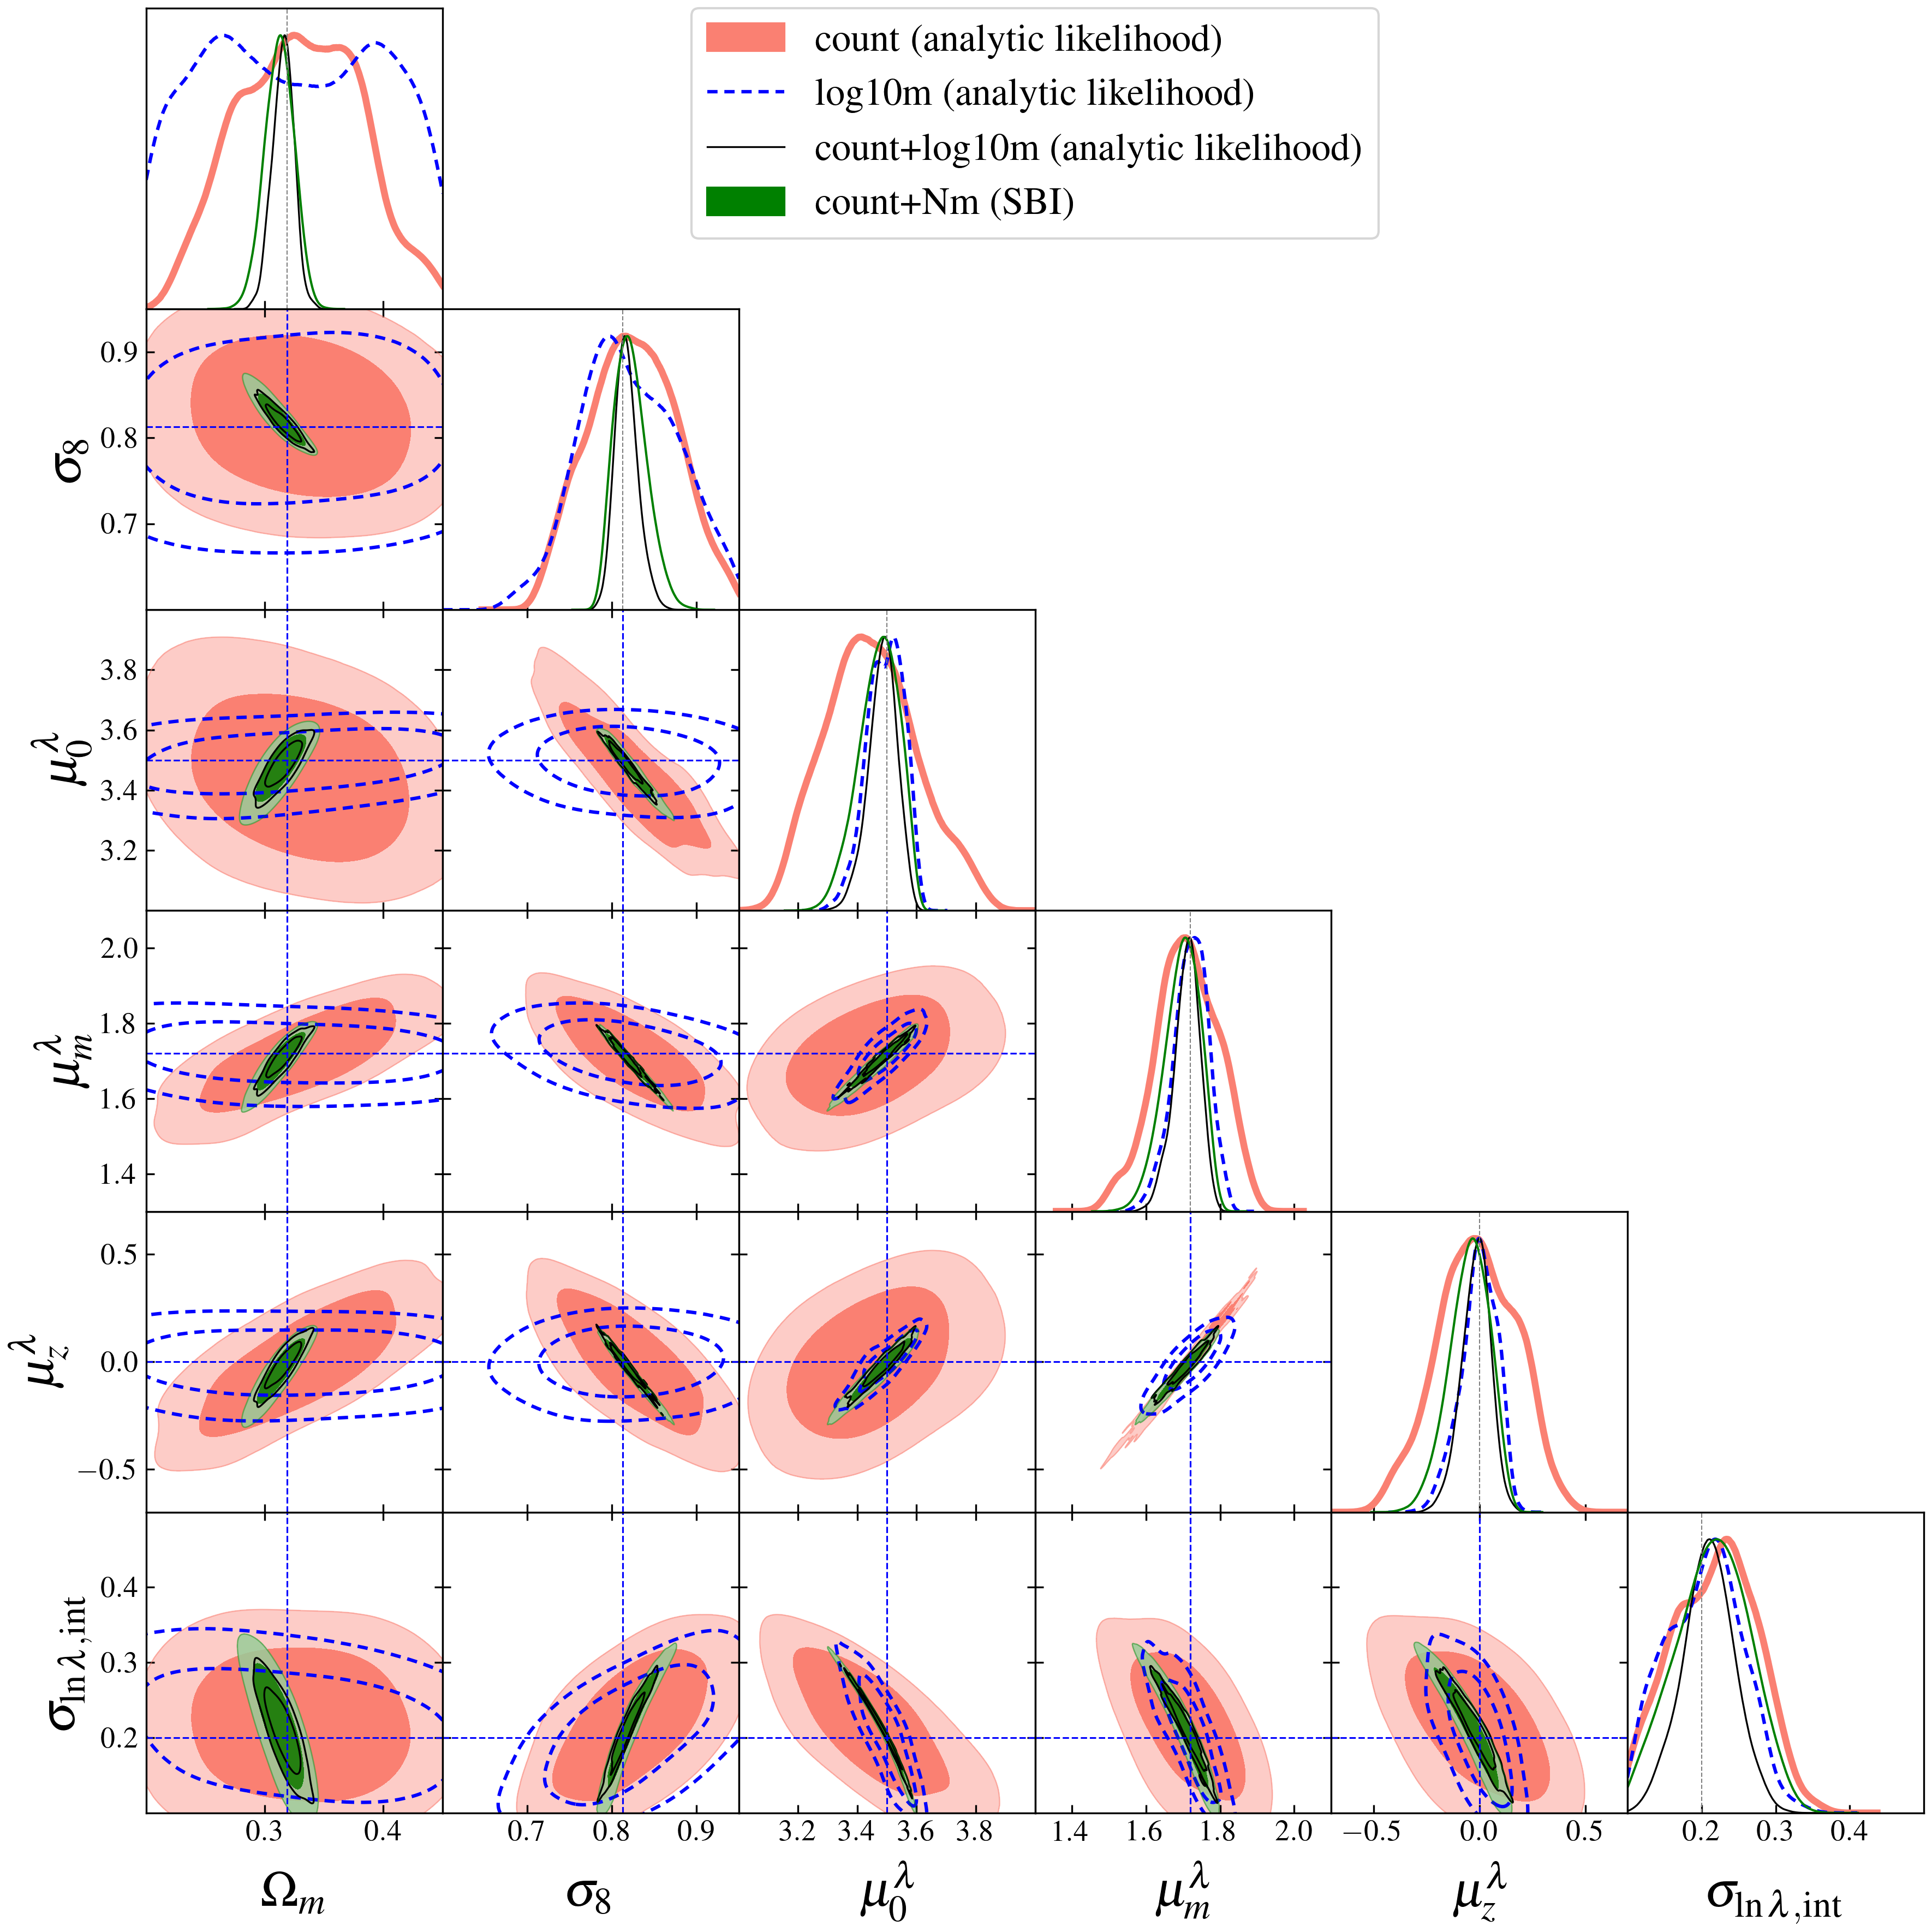

In [28]:
g = plots.get_subplot_plotter(subplot_size=2)
g.settings.lab_fontsize = 25
g.settings.axes_fontsize = 16
g.settings.legend_fontsize = 20
marker_args = {'lw':0.75, 'markersize':0.75, 'ls':'--','color':'b'}
#range_ = {'1':[0.2, 0.5], '2':[0.6,0.9], '3':[2.5,4.5], '4':[1, 2.5],'5':[-1,1], '6':[0.1, 0.5], }
g.triangle_plot([N_mcmc, m_mcmc,Nm_mcmc, count_Nm, ],
                #[N_Nm_power_law_log10Mwl_no_scatter],
                filled=[True, False, False,True,False, False], 
                contour_colors = ['salmon', 'b', 'k','g',  ], 
                contour_ls=['-','--','-','-','-','--',],
                contour_lws=[3,1.5,0.8,1,1.5,1.5],
                #shaded=[False, False, True],
                legend_fontsize = 10,
                params=['1','2','3','4','5','6'],
                markers=markers,
                param_limits = range_,
                fine_bins = 5,  
                marker_args = marker_args)
plt.savefig(f'mcmc_standard_likelihood.png', dpi = 300)

In [70]:
# g = plots.get_subplot_plotter(subplot_size=2)
# g.settings.lab_fontsize = 25
# g.settings.axes_fontsize = 16
# g.settings.legend_fontsize = 20
# marker_args = {'lw':0.75, 'markersize':0.75, 'ls':'--','color':'b'}
# #range_ = {'1':[0.2, 0.5], '2':[0.6,0.9], '3':[2.5,4.5], '4':[1, 2.5],'5':[-1,1], '6':[0.1, 0.5], }
# g.triangle_plot([N_mcmc, m_mcmc, Nm_mcmc,count_Nm ],
#                 filled=[True, False, True,False, False, False], 
#                 contour_colors = ['C0', 'r', 'g','b', 'r', 'g',  ], 
#                 contour_ls=['-','-','-','-','--','--',],
#                 contour_lws=[3,3,3,1,1.5,1.5],
#                 #shaded=[False, False, True],
#                 legend_fontsize = 10,
#                 params=['1','2','3','4','5','6'],
#                 markers=markers,
#                 param_limits = range_,
#                 fine_bins = 5,  
#                 marker_args = marker_args)
# plt.savefig(f'mcmc_standard_likelihood.png', dpi = 300)

In [71]:
path = '../../capish_sbi_data/config_sbi_DESlike6_corrected_standard_prior_6_params/samples_of_{}_posterior_with_data_flagship_sim.pkl'

t = np.load(path.format('count_Nm'), allow_pickle = True)
count_Nm_flagship_TK10 = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count+Nm (SBI:TK10, Flagship)')

path = '../../capish_sbi_data/config_sbi_DESlike6_TK08_corrected_standard_prior_6_params/samples_of_{}_posterior_with_data_flagship_sim.pkl'

t = np.load(path.format('count_Nm'), allow_pickle = True)
count_Nm_flagship_TK08 = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count+Nm (SBI:TK08, Flagship)')

Removed no burn in
Removed no burn in


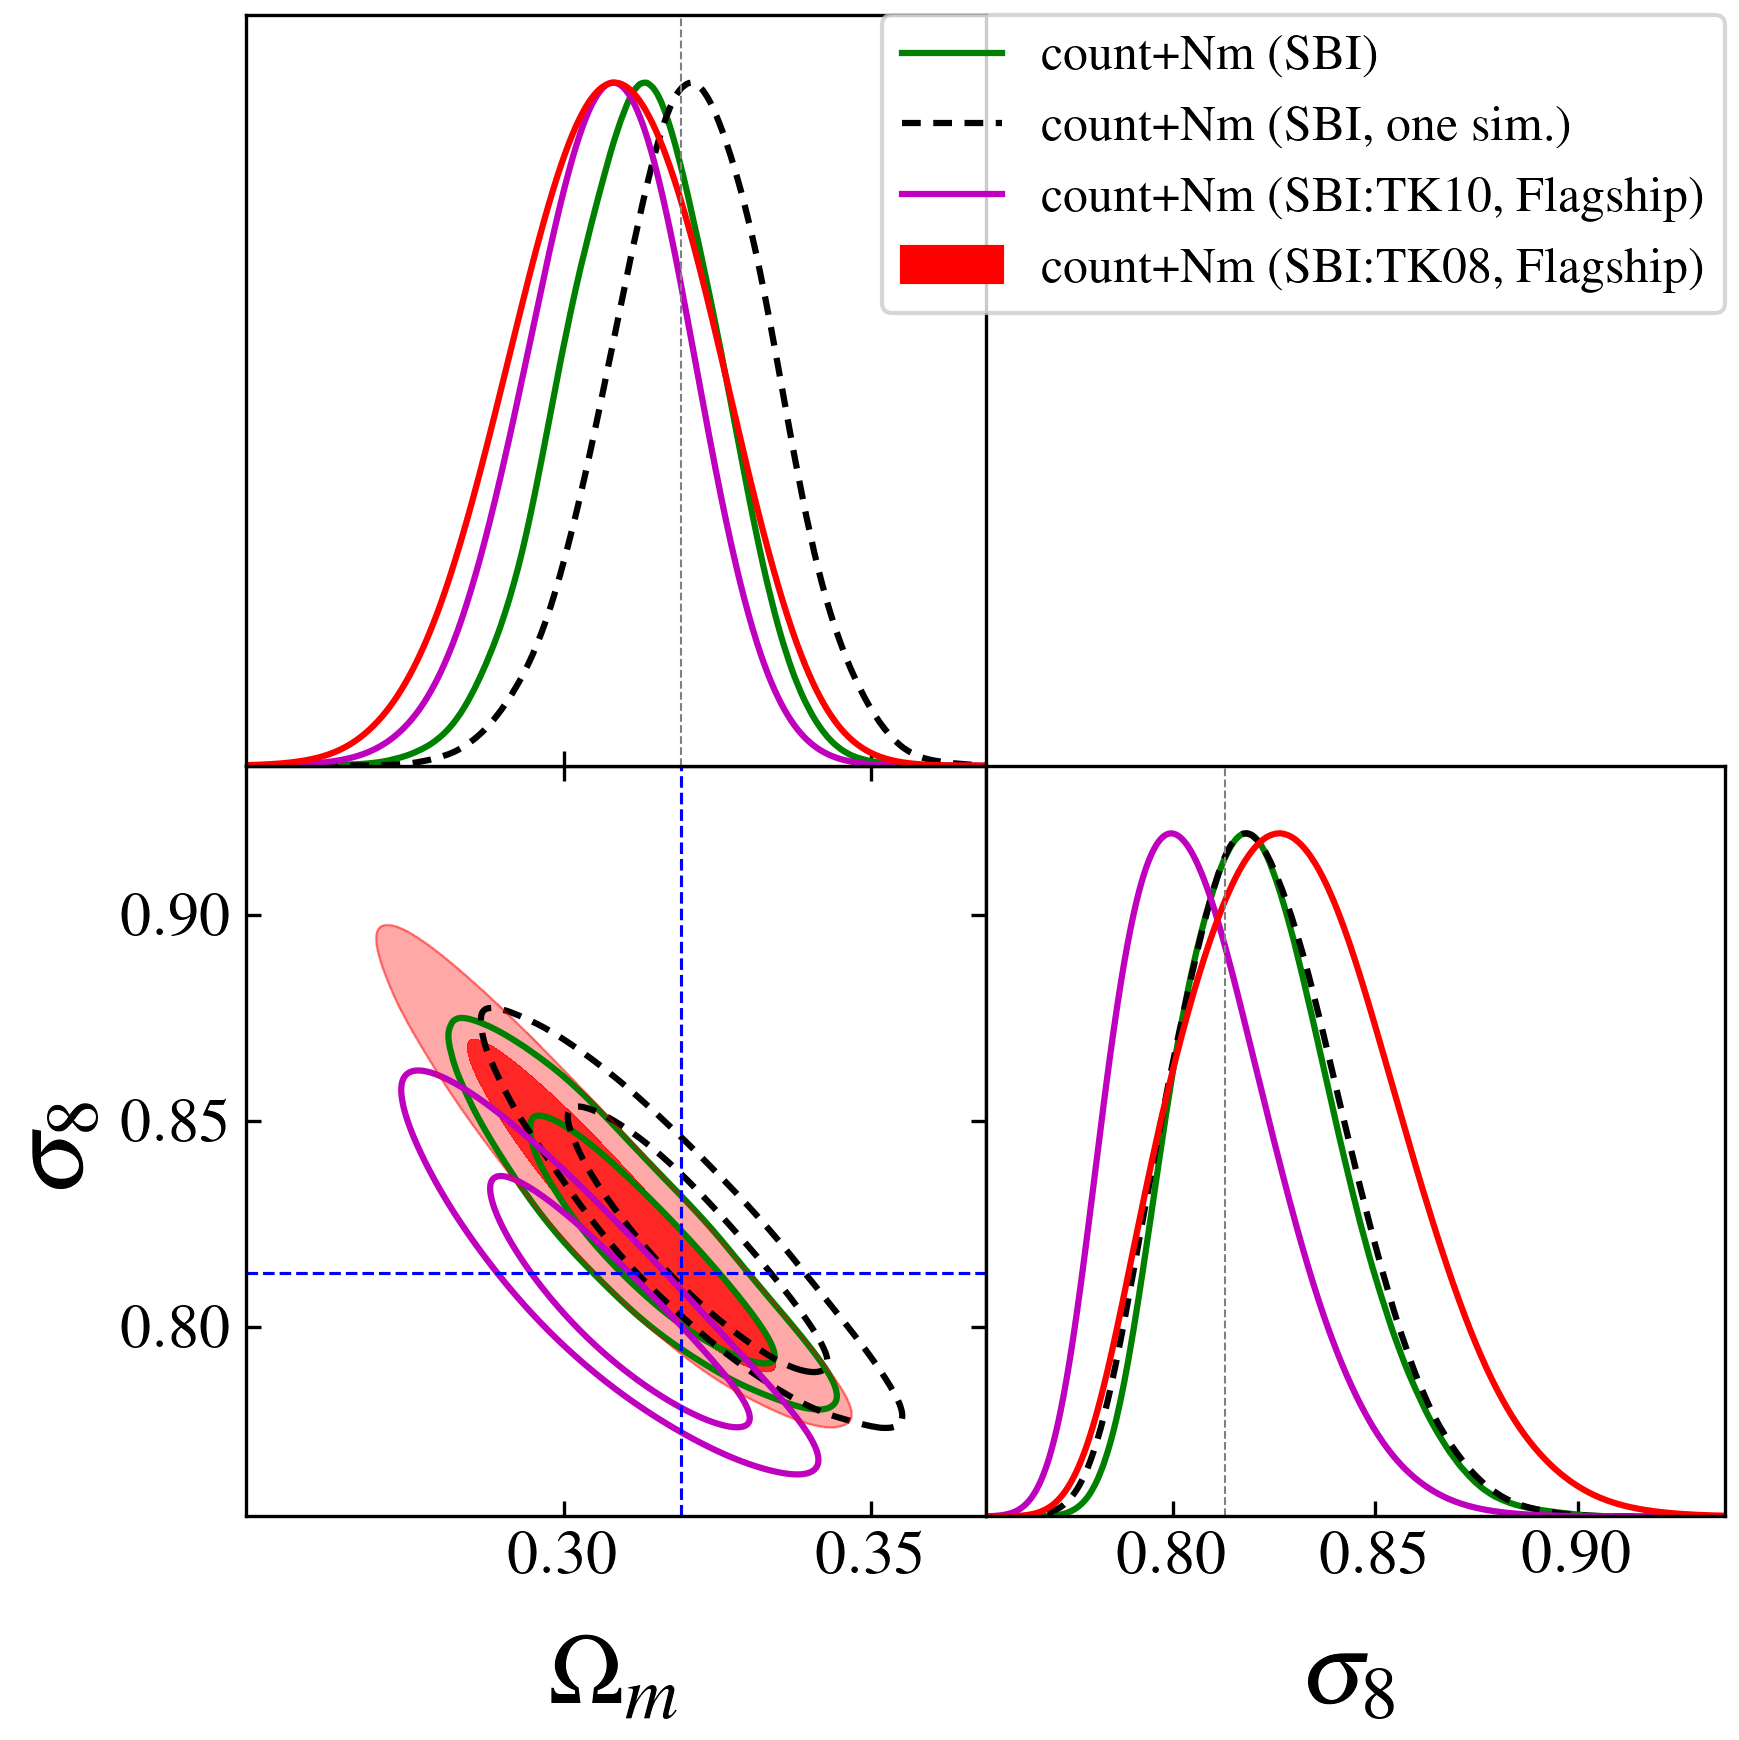

In [110]:
g = plots.get_subplot_plotter(subplot_size=3)
g.settings.lab_fontsize = 25
g.settings.axes_fontsize = 16
g.settings.legend_fontsize = 13
marker_args = {'lw':0.75, 'markersize':0.75, 'ls':'--','color':'b'}
#range_ = {'1':[0.2, 0.5], '2':[0.6,0.9], '3':[2.5,4.5], '4':[1, 2.5],'5':[-1,1], '6':[0.1, 0.5], }
g.triangle_plot([count_Nm, count_Nm_onesim,count_Nm_flagship_TK10, count_Nm_flagship_TK08],
                filled=[False, False, False,True, False, False], 
                contour_colors = ['g', 'k', 'm','r', 'k', 'g',  ], 
                contour_ls=['-','--','-','-','-','--',],
                contour_lws=[1.5,1.5,1.5,1.5,1.5,1.5],
                #shaded=[False, False, True],
                legend_fontsize = 10,
                params=['1','2'
                       ],
                markers=markers,
                #param_limits = range_,
                fine_bins = 5,  
                marker_args = marker_args)
plt.savefig(f'mcmc_sbi_flagship.png', dpi = 300)

In [112]:
list_chains = [N, Nm, count_Nm, N_masked, log10m, N_log10m, count_Nm_no_selection_bias,
               count_Nm_selection_bias,
               count_Nm_onesim, 
                count_Nm_flagship_TK10,count_Nm_flagship_TK08]
for chain in list_chains:
    means = chain.mean(['1', '2', '3', '4', '5', '6'])
    errors = np.diagonal(chain.cov(['1', '2', '3', '4', '5', '6']))**.5
    a = str(chain.label)
    for i, n in enumerate(['1', '2', '3', '4', '5', '6']):
        a += f' & ${means[i]:.3f} \pm {errors[i]:.3f}$ '
    a += '\{}'.format('\\')
    print(a)

count (SBI) & $0.343 \pm 0.058$  & $0.845 \pm 0.055$  & $3.396 \pm 0.174$  & $1.704 \pm 0.078$  & $-0.029 \pm 0.176$  & $0.214 \pm 0.053$ \\
Nm (SBI) & $0.314 \pm 0.029$  & $0.804 \pm 0.068$  & $3.533 \pm 0.255$  & $1.649 \pm 0.136$  & $-0.094 \pm 0.221$  & $0.243 \pm 0.077$ \\
count+Nm (SBI) & $0.312 \pm 0.012$  & $0.823 \pm 0.019$  & $3.472 \pm 0.066$  & $1.697 \pm 0.048$  & $-0.049 \pm 0.093$  & $0.215 \pm 0.049$ \\
count-masked (SBI) & $0.330 \pm 0.061$  & $0.842 \pm 0.062$  & $3.417 \pm 0.172$  & $1.694 \pm 0.099$  & $-0.049 \pm 0.219$  & $0.217 \pm 0.054$ \\
log10m (SBI) & $0.330 \pm 0.059$  & $0.871 \pm 0.041$  & $3.530 \pm 0.061$  & $1.732 \pm 0.047$  & $0.055 \pm 0.083$  & $0.197 \pm 0.048$ \\
count+log10m masked (SBI) & $0.310 \pm 0.012$  & $0.829 \pm 0.019$  & $3.441 \pm 0.065$  & $1.677 \pm 0.047$  & $-0.077 \pm 0.094$  & $0.237 \pm 0.044$ \\
count+Nm with selection bias fixed (SBI) & $0.317 \pm 0.011$  & $0.816 \pm 0.015$  & $3.491 \pm 0.055$  & $1.713 \pm 0.040$  & $-0.01

In [113]:
list_chains = [N_mcmc, m_mcmc, Nm_mcmc,]
for chain in list_chains:
    means = chain.mean(['1', '2', '3', '4', '5', '6'])
    errors = np.diagonal(chain.cov(['1', '2', '3', '4', '5', '6']))**.5
    a = str(chain.label)
    for i, n in enumerate(['1', '2', '3', '4', '5', '6']):
        a += f' & ${means[i]:.3f} \pm {errors[i]:.3f}$ '
    a += '\{}'.format('\\')
    print(a)

count (analytic likelihood) & $0.327 \pm 0.048$  & $0.824 \pm 0.048$  & $3.459 \pm 0.141$  & $1.710 \pm 0.083$  & $-0.012 \pm 0.180$  & $0.212 \pm 0.058$ \\
log10m (analytic likelihood) & $0.320 \pm 0.072$  & $0.823 \pm 0.055$  & $3.496 \pm 0.057$  & $1.721 \pm 0.044$  & $-0.002 \pm 0.082$  & $0.204 \pm 0.047$ \\
count+log10m (analytic likelihood) & $0.316 \pm 0.008$  & $0.816 \pm 0.012$  & $3.490 \pm 0.044$  & $1.713 \pm 0.032$  & $-0.012 \pm 0.062$  & $0.206 \pm 0.033$ \\


In [51]:
n_cut=490000
settings={'mult_bias_correction_order':0,'smooth_scale_2D':3, 'smooth_scale_1D':4, 'boundary_correction_order':0}
path = '../../capish_sbi_data/config_sbi_selection_bias_corrected_standard_prior_7_params/samples_of_{}_posterior_with_data_flagship_like_sim.pkl'

t = np.load(path.format('count_Nm'), allow_pickle = True)
print(t.shape)
count_Nm_selection_bias = MCSamples(samples=t[n_cut:],names = names + ['7'], 
                    labels = labels  + [r'\rho'], 
                     settings=settings, 
                     label=r'count+Nm with free selection bias (SBI)')

(500000, 7)
Removed no burn in


In [52]:
n_cut = 490000
path = '../../capish_sbi_data/config_sbi_selection_bias_default_corrected_standard_prior_6_params/samples_of_{}_posterior_with_data_flagship_like_sim.pkl'

t = np.load(path.format('count_Nm'), allow_pickle=True)

# add dummy parameter column
empty_col = np.full((t.shape[0], 1), 0)
t_extended = np.hstack((t, empty_col))
t_extended[:,6] = t_extended[:,1]

count_Nm_no_selection_bias = MCSamples(
    samples=t_extended[n_cut:],
    names=names + ['7'],
    labels=labels + [r'\rho'],
    settings=settings,
    label=r'count+Nm with selection bias fixed (SBI)'
)

Removed no burn in


In [53]:
count_Nm_no_selection_bias.cov('7')

array([[0.00023359]])

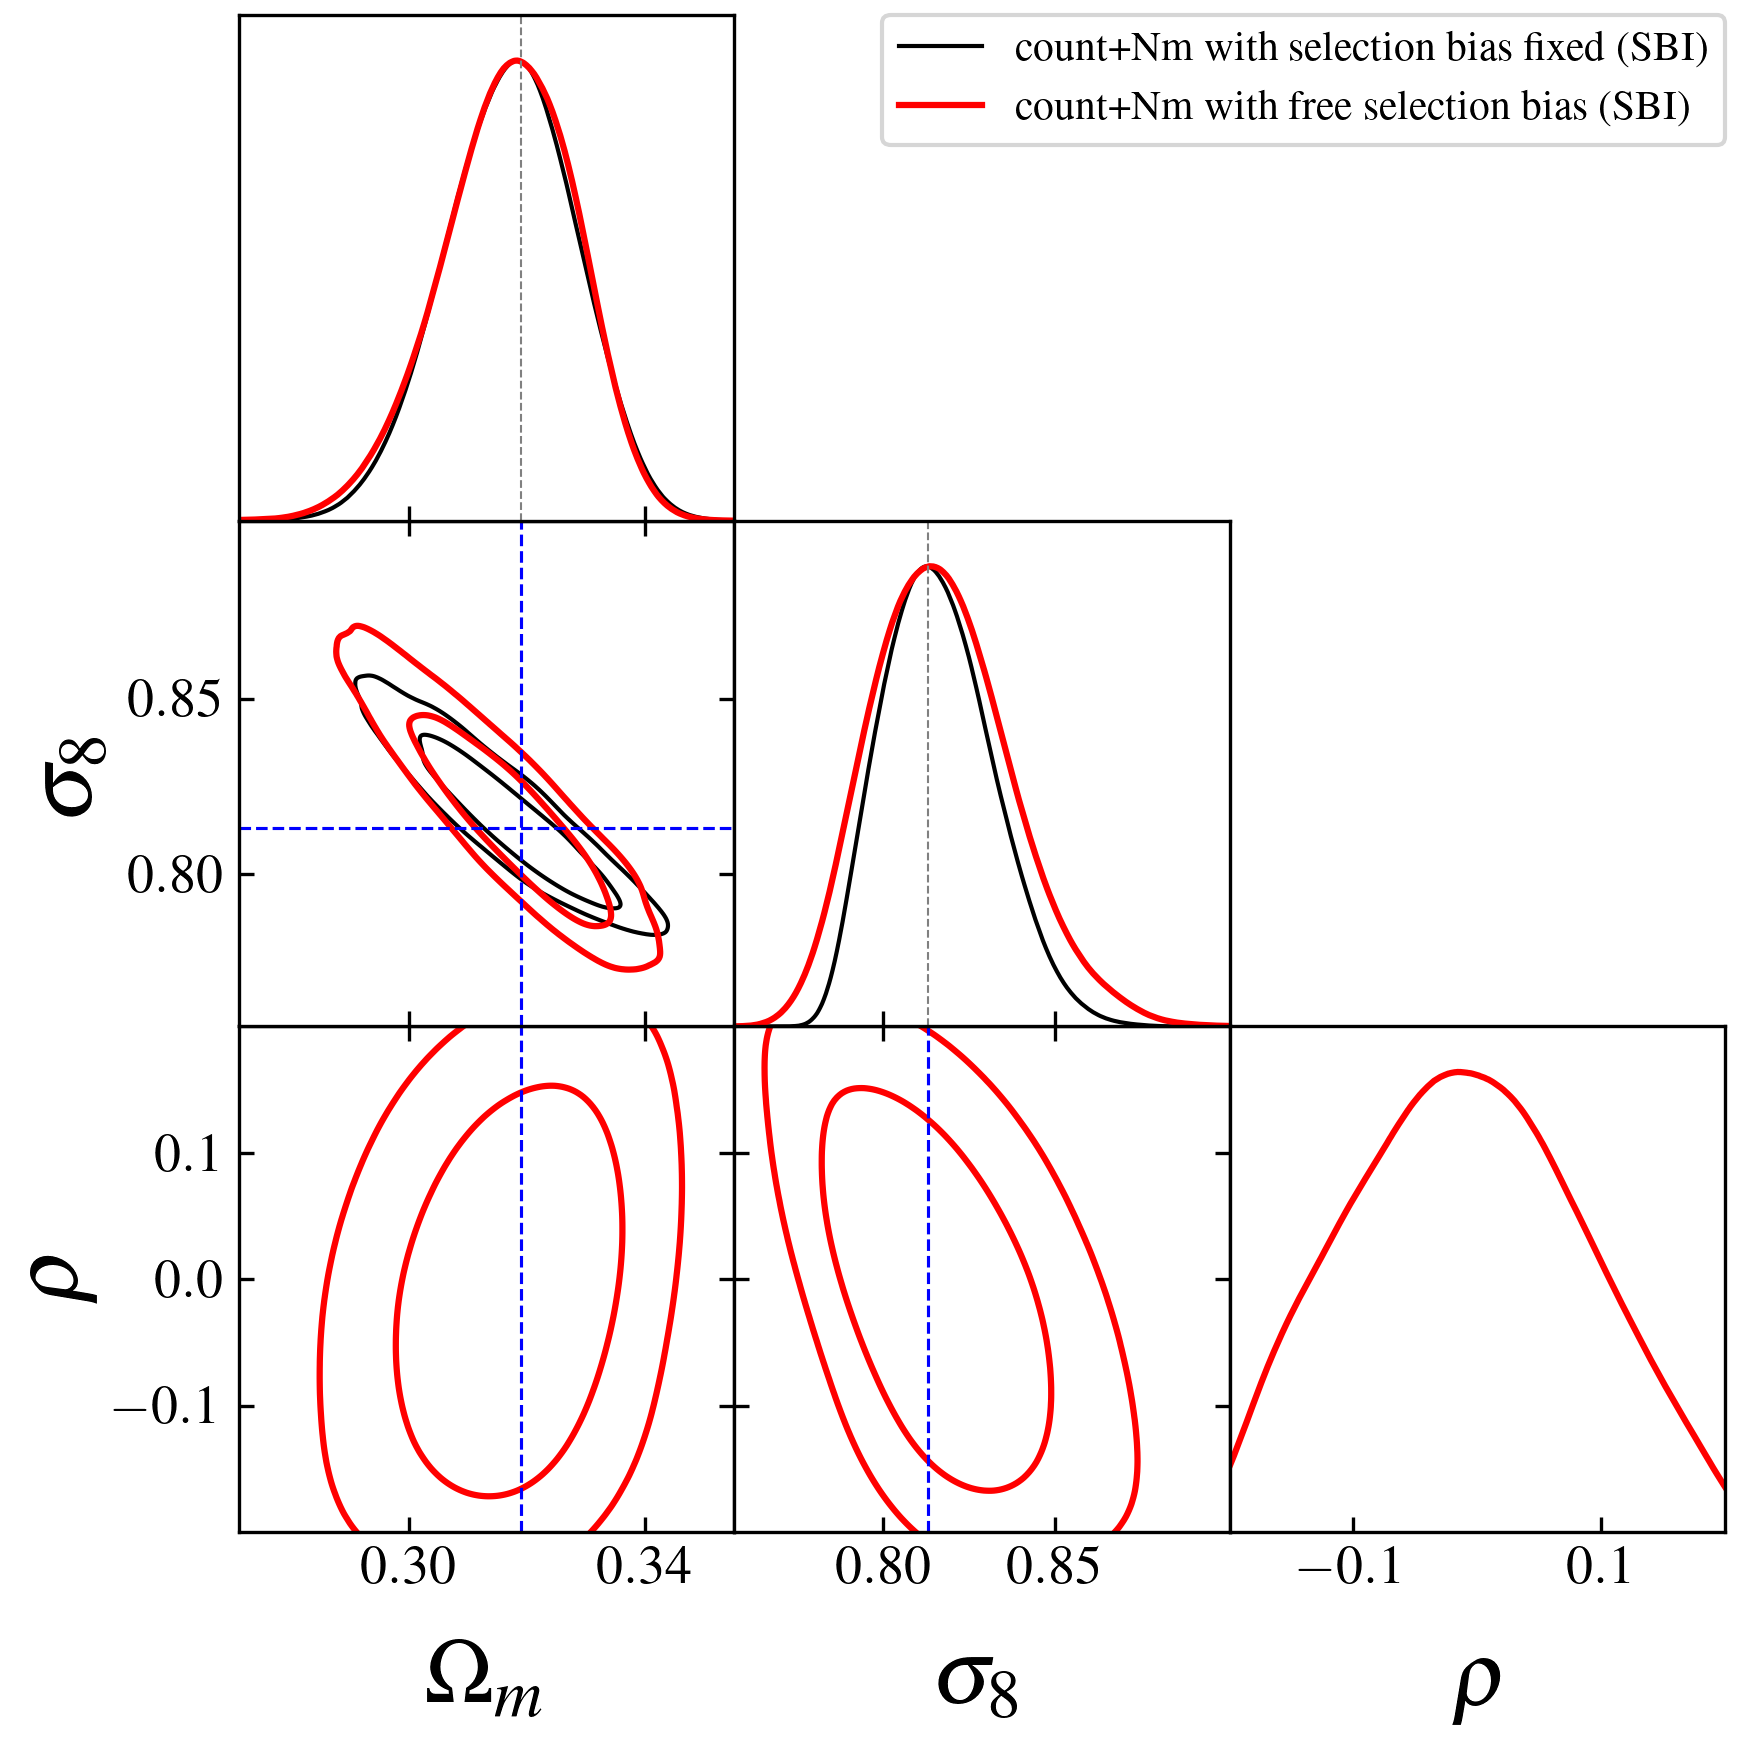

In [79]:
g = plots.get_subplot_plotter(subplot_size=2)
g.settings.lab_fontsize = 25
g.settings.axes_fontsize = 16
g.settings.legend_fontsize = 13
marker_args = {'lw':0.75, 'markersize':0.75, 'ls':'--','color':'b'}
#range_ = {'1':[0.2, 0.5], '2':[0.6,0.9], '3':[2.5,4.5], '4':[1, 2.5],'5':[-1,1], '6':[0.1, 0.5], }
g.triangle_plot([count_Nm_no_selection_bias, count_Nm_selection_bias , ],
                filled=[False, False, False,False, False, False], 
                contour_colors = ['k', 'r', 'g','b', 'k', 'g',  ], 
                contour_ls=['-','-','-','-','-','--',],
                contour_lws=[1,1.5,3,1,1.5,1.5],
                #shaded=[False, False, True],
                legend_fontsize = 10,
                params=['1','2','7'
                       ],
                markers=markers,
                param_limits = {'7': [-0.2, 0.2]},
                fine_bins = 5,  
                marker_args = marker_args)
plt.savefig(f'mcmc_sbi_selection_bias.png', dpi = 300)